In [1]:
import numpy as np
import pickle
from qiskit_nature.second_q.operators import SpinOp
from qiskit_nature.second_q.mappers import LogarithmicMapper
n_qubit = 1
dim     = 2**n_qubit
mapper = LogarithmicMapper()
t = 0.5
nld = 11
lds = np.linspace(0,1,num=nld)
Hld = []
i = 0
for ld in lds:
    h = SpinOp({
        "X_0": t,  
        "Z_0": -1.0 + 2.0* ld
    },
    spin=1/2
    )
    Hld.append(2*mapper.map(h.simplify())) # 2 is due to spin 1/2
    print(Hld[i])
    i +=1
h = SpinOp({
    "Z_0": 2.0
},
spin=1/2
)
Hp = 2*mapper.map(h.simplify()) # 2 is due to spin 1/2

# exact eigenvalues
ell  = np.zeros((nld,dim),dtype=float)
vll  = np.zeros((nld,dim,dim),dtype=complex)
for ild in range(nld):
    El, Vl = np.linalg.eigh(Hld[ild].to_matrix())
    indx = np.argsort(El.real)
    for i in range(dim):
        ell[ild,i]   = El[indx[i]].real
        vll[ild,:,i] = Vl[:,indx[i]]

X = np.zeros((2,2),dtype=complex)
Y = np.zeros((2,2),dtype=complex)
Z = np.zeros((2,2),dtype=complex)

X[0,1] = 1; X[1,0] = 1
Y[0,1] = -1j; Y[1,0] = 1j
Z[0,0] = 1; Z[1,1] = -1

# exact results
norm_exact   = np.ones((nld,dim),dtype=float)
E_exact      = np.zeros((nld,dim),dtype=float)
E_exact[0,:] = ell[0,:]
for k in range(dim):
    phi = vll[0,:,k]
    for ild in range(1,nld):
        Proj_matrix = np.outer(vll[ild,:,k],vll[ild,:,k].conj())
        phi = Proj_matrix@phi
        norm_exact[ild,k] = phi.conj()@phi
        E_exact[ild,k] = phi.conj()@Hld[ild].to_matrix()@phi/norm_exact[ild,k]
X_exact = np.zeros((nld,dim),dtype=float)
Y_exact = np.zeros((nld,dim),dtype=float)
Z_exact = np.zeros((nld,dim),dtype=float)
for ild in range(nld):
    for k in range(dim):
        X_exact[ild,k] = vll[ild,:,k].conj().transpose()@X@vll[ild,:,k]
        Y_exact[ild,k] = vll[ild,:,k].conj().transpose()@Y@vll[ild,:,k]
        Z_exact[ild,k] = vll[ild,:,k].conj().transpose()@Z@vll[ild,:,k]

0.5 * X
- 1.0 * Z
0.5 * X
- 0.8 * Z
0.5 * X
- 0.6 * Z
0.5 * X
- 0.3999999999999999 * Z
0.5 * X
- 0.19999999999999996 * Z
0.5 * X
0.5 * X
+ 0.20000000000000018 * Z
0.5 * X
+ 0.40000000000000013 * Z
0.5 * X
+ 0.6000000000000001 * Z
0.5 * X
+ 0.8 * Z
0.5 * X
+ 1.0 * Z


/home/mchan/qiskit/venv/lib/python3.8/site-packages/qiskit_nature/second_q/mappers/qubit_mapper.py:188: PauliSumOpDeprecationWarning: PauliSumOp is deprecated as of version 0.6.0 and support for them will be removed no sooner than 3 months after the release. Instead, use SparsePauliOp. You can switch to SparsePauliOp immediately, by setting `qiskit_nature.settings.use_pauli_sum_op` to `False`.
  qubit_ops[name] = self._map_single(second_q_op, register_length=register_length)
/tmp/ipykernel_1271/986796965.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  norm_exact[ild,k] = phi.conj()@phi
/tmp/ipykernel_1271/986796965.py:58: ComplexWarning: Casting complex values to real discards the imaginary part
  E_exact[ild,k] = phi.conj()@Hld[ild].to_matrix()@phi/norm_exact[ild,k]
/tmp/ipykernel_1271/986796965.py:64: ComplexWarning: Casting complex values to real discards the imaginary part
  X_exact[ild,k] = vll[ild,:,k].conj().transpose()@X@vll[ild,:,k]
/tmp/ipy

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Estimator, Session, Options
from qiskit.providers import JobStatus
import time as time_lib

service = QiskitRuntimeService(channel="ibm_quantum")
backend_name = "ibmq_lima" # use ibmq_lima(5-qubit, minimum pending jobs)

def accumulate_job_results (service, job_ids):
    results = np.array([],dtype=float)
    for job_id in job_ids:
        job = service.job(job_id)
        while job.status() is not JobStatus.DONE:
            time_lib.sleep(5) 
        results = np.append(results,job.result().values)
    return results

In [3]:

nmc = int(4E2)

In [16]:
Emc      = np.zeros((nld,dim),dtype=float)
normmc   = np.zeros((nld,dim),dtype=float)
dE1norm_raw = np.zeros((nmc,nld,dim),dtype=float)
normmc_raw = np.zeros((nmc,nld,dim),dtype=float)

job_ids_save = []
max_save = 0
with open('ibmq_lima.save.formatted','r') as file_:
    for line in file_:
        job_ids = (line.split())[1:]
        job_ids_save.append(job_ids)

nhp = len(Hp)
ind_save = 0
for k in range(dim):
    normmc[0,k]   = 1
    Emc[0,k]      = ell[0,k]
    eps = vll[0,:,k].conj().T@Hld[1].to_matrix()@vll[0,:,k] # first order perturbated energy
    eps = eps.real
    ind_start = 1
    for ild in range(ind_start,nld):
        with Session(service=service, backend=backend_name) as session:
            job_ids = job_ids_save[ind_save]
            result_values = accumulate_job_results(session.service, job_ids)

        for imc in range(nmc):
            normmc_raw[imc,ild,k] = result_values[imc]

        dE1norm_raw[:,ild,k] = 0.0
        for ihp in range(nhp):
            if (nhp==1):
                coeff = float(Hp.to_pauli_op().coeff)
            else:
                coeff = float(Hp.to_pauli_op()[ihp].coeff)
            for imc in range(nmc):
                dE1norm_raw[imc,ild,k] += coeff * result_values[nmc*(ihp+1)+imc]

        dE2norm = 0.0
        for ihp in range(nhp):
            if (nhp==1):
                coeff = float(Hp.to_pauli_op().coeff)
            else:
                coeff = float(Hp.to_pauli_op()[ihp].coeff)
            for imc in range(nmc):
                dE2norm += coeff * result_values[nmc*(ihp+nhp+1)+imc]

        norm    = 0.0
        dE1norm = 0.0
        for imc in range(nmc):
            norm += normmc_raw[imc,ild,k]
            dE1norm += dE1norm_raw[imc,ild,k]

        dE1   = dE1norm/norm
        dE2   = dE2norm/norm
        norm  = norm/nmc
        
        Emc[ild,k] = Emc[ild-1,k] + dE1 * (lds[ild]-lds[ild-1])
        normmc[ild,k] = norm

        if (ild<nld-1):
            eps = Emc[ild,k] + dE2*(lds[ild+1]-lds[ild])
        print(ild, norm, (Emc[ild,k]-ell[ild,k])/(ell[ild,k])*100)
        if (ild<nld-1):
            print(ild, norm, eps ,ell[ild+1,k])
        st = '# {i}/{dim}: {percent}%'.format(i=k+1,dim=dim,percent=((ild)/(nld-1)*100))
        print(st)
        ind_save += 1

1 0.9621189382403419 -0.10857050365645066
1 0.9621189382403419 -0.772939032215143 -0.7810249675906655
# 1/2: 10.0%
2 0.958892405615184 -0.041196583615384766
2 0.958892405615184 -0.6272306728135484 -0.6403124237432848
# 1/2: 20.0%
3 0.9494518419691877 0.015713195967292815
3 0.9494518419691877 -0.5168914854914793 -0.5385164807134504
# 1/2: 30.0%
4 0.9248525386554333 0.13740581508845262
4 0.9248525386554333 -0.46350606410942224 -0.5
# 1/2: 40.0%
5 0.8753369430449665 0.41633622500789613
5 0.8753369430449665 -0.5026580842937777 -0.5385164807134505
# 1/2: 50.0%
6 0.847417580547113 -0.24964081513845765
6 0.847417580547113 -0.6088167703214986 -0.640312423743285
# 1/2: 60.0%
7 0.8425690698301324 -0.07808634572683996
7 0.8425690698301324 -0.7697921918083598 -0.7810249675906655
# 1/2: 70.0%
8 0.8240057653419496 -0.31986664132240855
8 0.8240057653419496 -0.9294392774863995 -0.9433981132056604
# 1/2: 80.0%
9 0.8397343616809809 -0.5790157674278912
9 0.8397343616809809 -1.1058931954210252 -1.11803398

In [17]:
# standard deviation calculation with the bootstrap method
import random as rd
std_norm = np.zeros((nld,dim),dtype=float)
std_dE = np.zeros((nld,dim),dtype=float)
std_E = np.zeros((nld,dim),dtype=float)
n_boot = 1000
for k in range(dim):
    for ild in range(1,nld):
        norm_boot = np.zeros((n_boot),dtype=float)
        dE_boot   = np.zeros((n_boot),dtype=float)
        for i_boot in range(n_boot):
            norm_ = 0.0
            dE_   = 0.0
            for imc in range(nmc):
                jmc = rd.randrange(nmc)
                norm_ += normmc_raw[jmc,ild,k]
                dE_ += dE1norm_raw[jmc,ild,k]
            dE_   = dE_/norm_
            norm_ = norm_/nmc
            norm_boot[i_boot] = norm_
            dE_boot[i_boot] = dE_
        norm_boot_mean = 0.0
        dE_boot_mean   = 0.0
        for i_boot in range(n_boot):
            norm_boot_mean += norm_boot[i_boot]
            dE_boot_mean   += dE_boot[i_boot]
        norm_boot_mean /= n_boot
        dE_boot_mean /= n_boot

        var_norm = 0.0
        var_dE = 0.0
        for i_boot in range(n_boot):
            var_norm += (norm_boot[i_boot]-norm_boot_mean)**2
            var_dE += (dE_boot[i_boot]-dE_boot_mean)**2
        var_norm /= (n_boot-1)
        var_dE    /= (n_boot-1)
        std_norm[ild,k] = np.sqrt(var_norm)
        std_dE[ild,k] = np.sqrt(var_dE) * (lds[ild]-lds[ild-1])
        std_E[ild,k] = std_E[ild-1,k] + std_dE[ild,k]**2
for k in range(dim):
    for ild in range(1,nld):
        std_E[ild,k] = np.sqrt(std_E[ild,k])
        print(std_norm[ild,k],std_dE[ild,k],std_E[ild,k])

0.0011318922053360078 0.0004724374050405103 0.0004724374050405103
0.0011513663040737749 0.0006943323512686691 0.0008398181444215704
0.0013809030191883735 0.0010159239234221284 0.001318103157526413
0.0024282152890218785 0.0017125986165195987 0.0021611085014838897
0.003865479011865147 0.0026731904235992804 0.003437489926677436
0.005218323981905728 0.0032693232191830764 0.004743923619484028
0.005634268687525997 0.0030581149730963663 0.005644189799800732
0.0070264355912385236 0.0029286679575085644 0.006358771461651379
0.005843099136502968 0.0025005699885552843 0.0068327757733717106
0.006473061508475144 0.002284912353344895 0.007204696331674465
0.0010357010656286735 0.0003848825979426557 0.0003848825979426557
0.0010762317361333628 0.0005558526038802516 0.0006760966879371203
0.0012321744706419288 0.0008888951398655222 0.0011167995796543307
0.002136424311428699 0.001610274141127893 0.001959648976398902
0.003952195035545085 0.002617431541924068 0.0032697357672081496
0.004853683265198 0.0031069

In [18]:
# save to file
with open('norm.E.save','w') as file_:
    s = '# λ , norm_k^2, std(norm_k^2), E_k, std(E_k), k= 1, .., dim'
    s += '\n'
    file_.write(s)
    for ild in range(nld):
        s = '{:.16e}'.format(lds[ild])
        for k in range(dim):
            s += '  {:.16e}  {:.16e}  {:.16e}  {:.16e}'.format(normmc[ild,k],std_norm[ild,k],Emc[ild,k],std_E[ild,k])
        s += '\n'
        file_.write(s)

In [4]:
# xyz
# computation of the fidelity, <X>, <Y>, <Z>

Xmc      = np.zeros((nld,dim),dtype=float)
Ymc      = np.zeros((nld,dim),dtype=float)
Zmc      = np.zeros((nld,dim),dtype=float)
Fmc      = np.zeros((nld,dim),dtype=float)

normmc_raw = np.zeros((nmc,nld,dim),dtype=float)
Xnormmc_raw = np.zeros((nmc,nld,dim),dtype=float)
Ynormmc_raw = np.zeros((nmc,nld,dim),dtype=float)
Znormmc_raw = np.zeros((nmc,nld,dim),dtype=float)
Fnormmc_raw = np.zeros((nmc,nld,dim),dtype=float)

Xmc[0,:] = X_exact[0,:]
Ymc[0,:] = Y_exact[0,:]
Zmc[0,:] = Z_exact[0,:]
Fmc[0,:] = 1


job_ids_save = []
with open('./xyz/xyz_ibmq_lima.save.formatted','r') as file_:
    for line in file_:
        job_ids = (line.split())[1:]
        job_ids_save.append(job_ids)
ind_save = 0

for k in range(1):      # do only the ground state
    ind_start = 1
    for ild in range(ind_start,nld):
        with Session(service=service, backend=backend_name) as session:
            job_ids = job_ids_save[ind_save]
            result_values = accumulate_job_results(session.service, job_ids)

        for imc in range(nmc):
            normmc_raw[imc,ild,k]  = result_values[imc]
            Xnormmc_raw[imc,ild,k] = result_values[nmc+imc]
            Ynormmc_raw[imc,ild,k] = result_values[2*nmc+imc]
            Znormmc_raw[imc,ild,k] = result_values[3*nmc+imc]
            Fnormmc_raw[imc,ild,k] = result_values[4*nmc+imc]

        norm   = 0.0
        Xnorm  = 0.0
        Ynorm  = 0.0
        Znorm  = 0.0
        Fnorm  = 0.0

        for imc in range(nmc):
            norm += normmc_raw[imc,ild,k]

        for imc in range(nmc):
            Xnorm += Xnormmc_raw[imc,ild,k]

        for imc in range(nmc):
            Ynorm += Ynormmc_raw[imc,ild,k]

        for imc in range(nmc):
            Znorm += Znormmc_raw[imc,ild,k]

        for imc in range(nmc):
            Fnorm += Fnormmc_raw[imc,ild,k]

        Xmc[ild,k] = Xnorm/norm
        Ymc[ild,k] = Ynorm/norm
        Zmc[ild,k] = Znorm/norm
        Fmc[ild,k] = 0.5 * (1.0 + Fnorm/norm)
        norm  = norm/nmc

        
        st = '# {i}/{dim}: {percent}%'.format(i=k+1,dim=dim,percent=((ild)/(nld-1)*100))
        st_fidelity = ', |<Φ|Ψ>|^2 =  {fidelity}'.format(fidelity=Fmc[ild,k])
        print(st+st_fidelity)
        ind_save += 1

# 1/2: 10.0%, |<Φ|Ψ>|^2 =  1.0010252922461969
# 1/2: 20.0%, |<Φ|Ψ>|^2 =  0.9982973253038802
# 1/2: 30.0%, |<Φ|Ψ>|^2 =  1.0005941705688768
# 1/2: 40.0%, |<Φ|Ψ>|^2 =  0.9987937353426302
# 1/2: 50.0%, |<Φ|Ψ>|^2 =  1.0024718955029392
# 1/2: 60.0%, |<Φ|Ψ>|^2 =  1.0022760960081225
# 1/2: 70.0%, |<Φ|Ψ>|^2 =  1.001570586289629
# 1/2: 80.0%, |<Φ|Ψ>|^2 =  0.9983359920443873
# 1/2: 90.0%, |<Φ|Ψ>|^2 =  0.9934310081274278
# 1/2: 100.0%, |<Φ|Ψ>|^2 =  0.9983306087240134


In [5]:
import random as rd
std_X = np.zeros((nld,dim),dtype=float)
std_Y = np.zeros((nld,dim),dtype=float)
std_Z= np.zeros((nld,dim),dtype=float)
std_F= np.zeros((nld,dim),dtype=float)
n_boot = 1000
for k in range(1):
    for ild in range(1,nld):
        X_boot   = np.zeros((n_boot),dtype=float)
        Y_boot   = np.zeros((n_boot),dtype=float)
        Z_boot   = np.zeros((n_boot),dtype=float)
        F_boot   = np.zeros((n_boot),dtype=float)
        for i_boot in range(n_boot):
            norm_ = 0.0
            X_    = 0.0
            Y_    = 0.0
            Z_    = 0.0
            F_    = 0.0
            for imc in range(nmc):
                jmc = rd.randrange(nmc)
                norm_ += normmc_raw[jmc,ild,k]
                X_ += Xnormmc_raw[jmc,ild,k]
                Y_ += Ynormmc_raw[jmc,ild,k]
                Z_ += Znormmc_raw[jmc,ild,k]
                F_ += Fnormmc_raw[jmc,ild,k]
            X_ = X_/norm_
            Y_ = Y_/norm_
            Z_ = Z_/norm_
            F_ = 0.5 * (1.0 + F_/norm_) 
            X_boot[i_boot] = X_
            Y_boot[i_boot] = Y_
            Z_boot[i_boot] = Z_
            F_boot[i_boot] = F_
        X_boot_mean   = 0.0
        Y_boot_mean   = 0.0
        Z_boot_mean   = 0.0
        F_boot_mean   = 0.0
        for i_boot in range(n_boot):
            X_boot_mean   += X_boot[i_boot]
            Y_boot_mean   += Y_boot[i_boot]
            Z_boot_mean   += Z_boot[i_boot]
            F_boot_mean   += F_boot[i_boot]
        X_boot_mean /= n_boot
        Y_boot_mean /= n_boot
        Z_boot_mean /= n_boot
        F_boot_mean /= n_boot

        var_norm = 0.0
        var_X = 0.0
        var_Y = 0.0
        var_Z = 0.0
        var_F = 0.0
        for i_boot in range(n_boot):
            var_X += (X_boot[i_boot]-X_boot_mean)**2
            var_Y += (Y_boot[i_boot]-Y_boot_mean)**2
            var_Z += (Z_boot[i_boot]-Z_boot_mean)**2
            var_F += (F_boot[i_boot]-F_boot_mean)**2
        var_X    /= (n_boot-1)
        var_Y    /= (n_boot-1)
        var_Z    /= (n_boot-1)
        var_F    /= (n_boot-1)
        std_X[ild,k] = np.sqrt(var_X) 
        std_Y[ild,k] = np.sqrt(var_Y) 
        std_Z[ild,k] = np.sqrt(var_Z) 
        std_F[ild,k] = np.sqrt(var_F) 
        print(ild,std_X[ild,k],std_Y[ild,k],std_Z[ild,k],std_F[ild,k])

1 0.004001445369756934 0.0036808737742320633 0.0026153170047234593 0.0008167958679599545
2 0.004721344330642423 0.004215122738923702 0.0037775533735615614 0.0008851390484120788
3 0.00510600190806897 0.006480777407961962 0.005934077307967475 0.0011823669147953731
4 0.005376928251980328 0.009351319257541384 0.011175673769945299 0.0017487120312661033
5 0.00630877152898382 0.013760284379943666 0.013896009996014605 0.003240236684064833
6 0.009762774130953089 0.01636212347564496 0.016774230257588445 0.004026912429586649
7 0.01434442762752009 0.019834194894669838 0.016296792670421403 0.00516650005859158
8 0.017227273593803466 0.019781702631371408 0.015648061144781823 0.005454566594580334
9 0.017811761790251398 0.02154811916201055 0.017020076395091753 0.006403536333626759
10 0.017925699699271817 0.02115359492129464 0.013698893218438918 0.0055499588750890965


In [9]:
# save to file
with open('xyz.save','w') as file_:
    s = '# λ , X, std(X), Y, std(Y), Z, std(Z), F, std(F)'
    for ild in range(nld):
        s = '{:.16e}'.format(lds[ild])
        for k in range(1):
            s += '  {:.16e}  {:.16e}  {:.16e}  {:.16e}  {:.16e}  {:.16e}  {:.16e}  {:.16e}'.format(Xmc[ild,k],std_X[ild,k],Ymc[ild,k],std_Y[ild,k],Zmc[ild,k],std_Z[ild,k],Fmc[ild,k],std_F[ild,k])
        s += '\n'
        file_.write(s)

<Figure size 3047.24x3047.24 with 0 Axes>

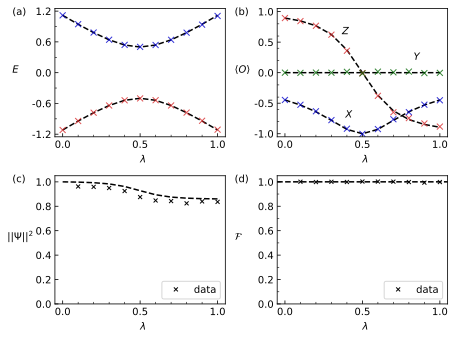

In [22]:
# draw figure
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cm    = 1.0/2.54
rat   = 1.5
width = 8.6*cm * 1.5
height = 8.6*cm  * 1.5
plt.figure(figsize=(width,height),dpi=600)

marker_style_ref = dict(marker='',linestyle='dashed',color='black')

marker_style_1_1  = dict(marker='s', linestyle='none', color='tab:red', alpha=0.4,  fillstyle='none')
marker_style_1_2  = dict(marker='s', linestyle='none', color='mediumblue', alpha=0.4,  fillstyle='none')
marker_style_1_3  = dict(marker='s', linestyle='none', color='darkgreen', alpha=0.4,  fillstyle='none')

marker_style_2_1  = dict(marker='D', linestyle='none', color='tab:red', alpha=0.6,  fillstyle='none')
marker_style_2_2  = dict(marker='D', linestyle='none', color='mediumblue', alpha=0.6,  fillstyle='none')
marker_style_2_3  = dict(marker='D', linestyle='none', color='darkgreen', alpha=0.6,  fillstyle='none')

marker_style_3_1  = dict(marker='x', linestyle='none', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_3_2  = dict(marker='x', linestyle='none', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_3  = dict(marker='x', linestyle='none', color='darkgreen', alpha=0.8,  fillstyle='none')

marker_style_4  = dict(marker='s', linestyle='none', color='black', alpha=1.0,  fillstyle='none')

marker_style_5  = dict(marker='D', linestyle='none', color='black', alpha=1.0,  fillstyle='none')

marker_style_6  = dict(marker='x', linestyle='none', color='black', alpha=1.0,  fillstyle='none')


fig, axes = plt.subplots(2,2)

# plot (a)

y_min    = -1.25
y_max    =  1.25

x_min    =  -0.05
x_max    =  1.05

axes[0,0].set_xlim(x_min,x_max)
axes[0,0].set_ylim(y_min,y_max)
# setup labels
axes[0,0].text(-0.25,0.95,'(a)',transform=axes[0,0].transAxes)
axes[0,0].text(0.5,-0.2,r'$\lambda$',transform=axes[0,0].transAxes)
axes[0,0].text(-0.25,0.5,r'$E$',transform=axes[0,0].transAxes)
# setup tics
axes[0,0].tick_params(axis='x', which='both', direction='in')
axes[0,0].tick_params(axis='y', which='both', direction='in')
axes[0,0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,0].xaxis.set_major_formatter('{x:0.1f}')
axes[0,0].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axes[0,0].yaxis.set_major_locator(ticker.MultipleLocator(0.6))
axes[0,0].yaxis.set_major_formatter('{x:0.1f}')
axes[0,0].yaxis.set_minor_locator(ticker.MultipleLocator(0.3))

# plot
axes[0,0].plot(lds,E_exact[:,0], label='', **marker_style_ref)
axes[0,0].plot(lds,E_exact[:,1], label='', **marker_style_ref)

axes[0,0].plot(lds,Emc[:,0], label='', markersize=6, **marker_style_3_1)
axes[0,0].plot(lds,Emc[:,1], label='', markersize=6, **marker_style_3_2)


# plot (b)
y_min    = -1.05
y_max    =  1.05

x_min    =  -0.05
x_max    =  1.05

axes[0,1].set_xlim(x_min,x_max)
axes[0,1].set_ylim(y_min,y_max)
# setup labels
axes[0,1].text(-0.25,0.95,'(b)',transform=axes[0,1].transAxes)
axes[0,1].text(0.5,-0.2,s=r'$\lambda$',transform=axes[0,1].transAxes)
axes[0,1].text(-0.25,0.5,s=r'$\langle O\rangle$',transform=axes[0,1].transAxes)


axes[0,1].text(0.4,0.15,s=r'$X$',transform=axes[0,1].transAxes)
axes[0,1].text(0.8,0.6,s=r'$Y$',transform=axes[0,1].transAxes)
axes[0,1].text(0.38,0.8,s=r'$Z$',transform=axes[0,1].transAxes)
# setup tics
axes[0,1].tick_params(axis='x', which='both', direction='in')
axes[0,1].tick_params(axis='y', which='both', direction='in')
axes[0,1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,1].xaxis.set_major_formatter('{x:0.1f}')
axes[0,1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axes[0,1].yaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,1].yaxis.set_major_formatter('{x:0.1f}')
axes[0,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.2))

# plot
axes[0,1].plot(lds,Z_exact[:,0], label='', **marker_style_ref)
axes[0,1].plot(lds,X_exact[:,0], label='', **marker_style_ref)
axes[0,1].plot(lds,Y_exact[:,0], label='', **marker_style_ref)

axes[0,1].plot(lds,Zmc[:,0], label ='', markersize=6, **marker_style_3_1)
axes[0,1].plot(lds,Xmc[:,0], label ='', markersize=6, **marker_style_3_2)
axes[0,1].plot(lds,Ymc[:,0], label ='', markersize=6, **marker_style_3_3)

# plot (c)
y_min    = 0.0
y_max    = 1.05

x_min    =  -0.05
x_max    =  1.05

axes[1,0].set_xlim(x_min,x_max)
axes[1,0].set_ylim(y_min,y_max)
# setup labels
axes[1,0].text(-0.25,0.95,'(c)',transform=axes[1,0].transAxes)
axes[1,0].text(0.5,-0.2,r'$\lambda$',transform=axes[1,0].transAxes)
axes[1,0].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[1,0].transAxes)
# setup tics
axes[1,0].tick_params(axis='x', which='both', direction='in')
axes[1,0].tick_params(axis='y', which='both', direction='in')
axes[1,0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[1,0].xaxis.set_major_formatter('{x:0.1f}')
axes[1,0].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axes[1,0].set_yscale('log')
axes[1,1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axes[1,1].yaxis.set_major_formatter('{x:0.1f}')
axes[1,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axes[1,0].plot(lds,norm_exact[:,0], label='', **marker_style_ref)

axes[1,0].plot(lds[1:],normmc[1:,0], label='data', markersize=4, **marker_style_6)

axes[1,0].legend(loc='lower right')

# plot (d)
y_min    = 0.0
y_max    = 1.05

x_min    =  -0.05
x_max    =  1.05

axes[1,1].set_xlim(x_min,x_max)
axes[1,1].set_ylim(y_min,y_max)
# setup labels
axes[1,1].text(-0.25,0.95,'(d)',transform=axes[1,1].transAxes)
axes[1,1].text(0.5,-0.2,r'$\lambda$',transform=axes[1,1].transAxes)
axes[1,1].text(-0.25,0.5,r'$\mathcal{F}$',transform=axes[1,1].transAxes)
# setup tics
axes[1,1].tick_params(axis='x', which='both', direction='in')
axes[1,1].tick_params(axis='y', which='both', direction='in')
axes[1,1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[1,1].xaxis.set_major_formatter('{x:0.1f}')
axes[1,1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axes[1,1].set_yscale('log')
axes[1,1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axes[1,1].yaxis.set_major_formatter('{x:0.1f}')
axes[1,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axes[1,1].axhline(y=1.0, label='', **marker_style_ref)


axes[1,1].plot(lds[1:],Fmc[1:,0], label='data', markersize=4, **marker_style_6)
axes[1,1].legend(loc='lower right')

plt.tight_layout()

In [9]:
# standard deviation calculation with the bootstrap method (use of poisson?)
# this approach overestimate error
#import random as rd
#std_norm = np.zeros((nld,dim),dtype=float)
#std_E = np.zeros((nld,dim),dtype=float)
#n_boot = 1000
#for k in range(dim):
#    dE_boot   = np.zeros((nld,n_boot),dtype=float)
#    for ild in range(1,nld):
#        norm_boot = np.zeros((n_boot),dtype=float)
#        for i_boot in range(n_boot):
#            norm_ = 0.0
#            dE_   = 0.0
#            for imc in range(nmc):
#                jmc = rd.randrange(nmc)
#                norm_ += normmc_raw[jmc,ild,k]
#                dE_ += dE1norm_raw[jmc,ild,k]
#            dE_   = dE_/norm_
#            norm_ = norm_/nmc
#            norm_boot[i_boot] = norm_
#            dE_boot[ild,i_boot] = dE_
#        norm_boot_mean = 0.0
#        for i_boot in range(n_boot):
#            norm_boot_mean += norm_boot[i_boot]
#        norm_boot_mean /= n_boot
#
#        var_norm = 0.0
#        for i_boot in range(n_boot):
#            var_norm += (norm_boot[i_boot]-norm_boot_mean)**2
#        var_norm /= (n_boot-1)
#        std_norm[ild,k] = np.sqrt(var_norm)
#    # energy std
#    dEld_boot = np.zeros((nld,n_boot),dtype=float)
#    for i_boot in range(n_boot):
#        dEld = np.zeros((nld),dtype=float)
#        for ild in range(1,nld):
#            j_boot = rd.randrange(n_boot)
#            dEld[ild] = dEld[ild-1] + dE_boot[ild,j_boot]
#            dEld_boot[ild,i_boot] = dEld[ild]
#
#    for ild in range(1,nld):
#        dEld_boot_mean = 0.0
#        for i_boot in range(n_boot):
#            dEld_boot_mean += dEld_boot[ild,i_boot]
#        dEld_boot_mean /= n_boot
#
#        var_E = 0.0
#        for i_boot in range(n_boot):
#            var_E += (dEld_boot[ild,i_boot]-dEld_boot_mean)**2
#        var_E /= (n_boot-1)
#        std_E[ild,k] = np.sqrt(var_E)
#        print(std_norm[ild,k],std_E[ild,k])

0.001118163816358948 0.00473041679312191
0.0011654536905269348 0.00822095939424504
0.0013589205288400785 0.013376316854235704
0.0023213374153665633 0.021405822039143305
0.003780057937742332 0.03419458919861934
0.0053932075831488995 0.0473554669719557
0.005448694943208407 0.055633612095546195
0.0068756697388667794 0.0613907218748792
0.005981942307276296 0.06562052269267242
0.0062570092042759946 0.0699377549186567
0.0010497345513133564 0.003977429741099043
0.001091710562301009 0.006775276388974367
0.0012982753396147955 0.01099911777155119
0.002090414900074284 0.01896268348978188
0.003766980239101335 0.032140920654174523
0.004928417343890087 0.04584117570076768
0.005428207203016183 0.054887383139854806
0.0059014506487001005 0.061432956342049004
0.005985310188617626 0.06668323868806211
0.00616863341540267 0.07116821433464068
